# ResNet-18

## Changes from Naive Baseline

### What changed
| | Naive | Unfreeze |
|---|---|---|
| Backbone | Frozen (only FC trains) | Unfrozen (all layers train) |
| Optimizer scope | `model.fc.parameters()` | `model.parameters()` |
| Learning rate | `1e-3` | `1e-4` |

### Rationale
In the naive version, the ResNet backbone was frozen â€” only the final classification layer (513 parameters out of ~11M) was trained. The backbone weights were fixed at ImageNet features, which are general-purpose and not specific to skin lesions.

By unfreezing the backbone, all ~11M parameters are fine-tuned on the HAM10000 dataset, allowing the model to adapt its feature extraction to the medical imaging domain.

A lower learning rate (`1e-4`) is used to avoid destroying the pretrained weights with large gradient updates early in training â€” the goal is to make small, careful adjustments to already-useful features rather than learning from scratch.

In [12]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [6]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [7]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([8.1117], device='cuda:0')


In [9]:
best_val_f2 = 0.0
num_epochs = 20
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), 'models/resnet_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8234, Bal Acc: 0.7755, Recall: 0.8301, F2: 0.5851 | Val Loss: 0.8330, Bal Acc: 0.7825, Recall: 0.8093, F2: 0.6075
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.6504, Bal Acc: 0.8355, Recall: 0.8689, F2: 0.6710 | Val Loss: 0.7592, Bal Acc: 0.7912, Recall: 0.8051, F2: 0.6201
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.5402, Bal Acc: 0.8664, Recall: 0.8962, F2: 0.7203 | Val Loss: 0.9057, Bal Acc: 0.7896, Recall: 0.6737, F2: 0.6250
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.4907, Bal Acc: 0.8823, Recall: 0.9019, F2: 0.7496 | Val Loss: 1.0486, Bal Acc: 0.7468, Recall: 0.5932, F2: 0.5547


Epoch [5/20] | Train Loss: 0.4360, Bal Acc: 0.8997, Recall: 0.9236, F2: 0.7785 | Val Loss: 0.7955, Bal Acc: 0.8162, Recall: 0.8136, F2: 0.6575
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.1069, Bal Acc: 0.9795, Recall: 0.9852, F2: 0.9478 | Val Loss: 1.4019, Bal Acc: 0.7974, Recall: 0.6949, F2: 0.6371


Epoch [17/20] | Train Loss: 0.1191, Bal Acc: 0.9764, Recall: 0.9852, F2: 0.9387 | Val Loss: 1.4541, Bal Acc: 0.8081, Recall: 0.7331, F2: 0.6523


Epoch [18/20] | Train Loss: 0.1493, Bal Acc: 0.9665, Recall: 0.9692, F2: 0.9209 | Val Loss: 1.7956, Bal Acc: 0.7626, Recall: 0.6102, F2: 0.5806


Epoch [19/20] | Train Loss: 0.1748, Bal Acc: 0.9628, Recall: 0.9692, F2: 0.9105 | Val Loss: 2.0421, Bal Acc: 0.7328, Recall: 0.5339, F2: 0.5285


Epoch [20/20] | Train Loss: 0.1174, Bal Acc: 0.9783, Recall: 0.9852, F2: 0.9441 | Val Loss: 1.4891, Bal Acc: 0.8174, Recall: 0.8983, F2: 0.6515


## Training Curves

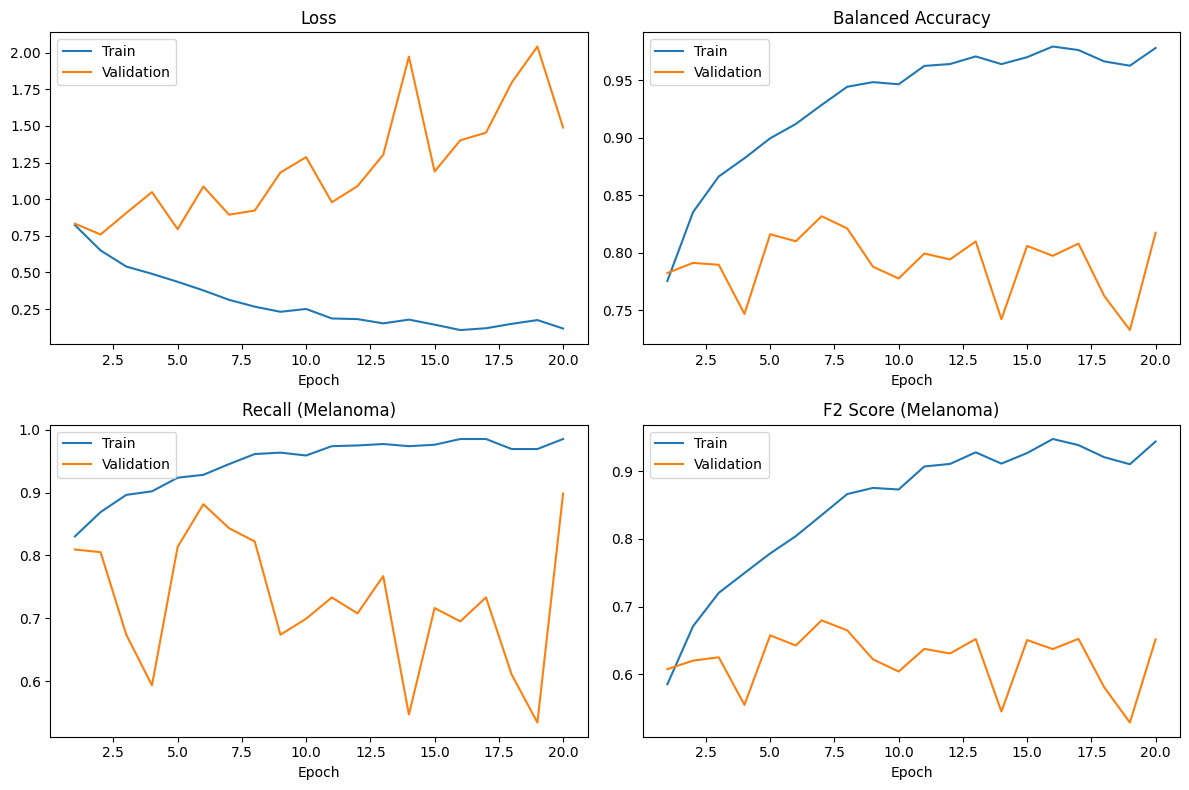

In [10]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [14]:
model.load_state_dict(torch.load('models/resnet_best.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.60 | Val F2: 0.6893


Threshold:          0.60
AUC-ROC:            0.8997
Balanced Accuracy:  0.7973
F2 Score:           0.6280

              precision    recall  f1-score   support

Non-Melanoma     0.9640    0.8403    0.8979      1340
    Melanoma     0.3761    0.7544    0.5019       171

    accuracy                         0.8306      1511
   macro avg     0.6701    0.7973    0.6999      1511
weighted avg     0.8975    0.8306    0.8531      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


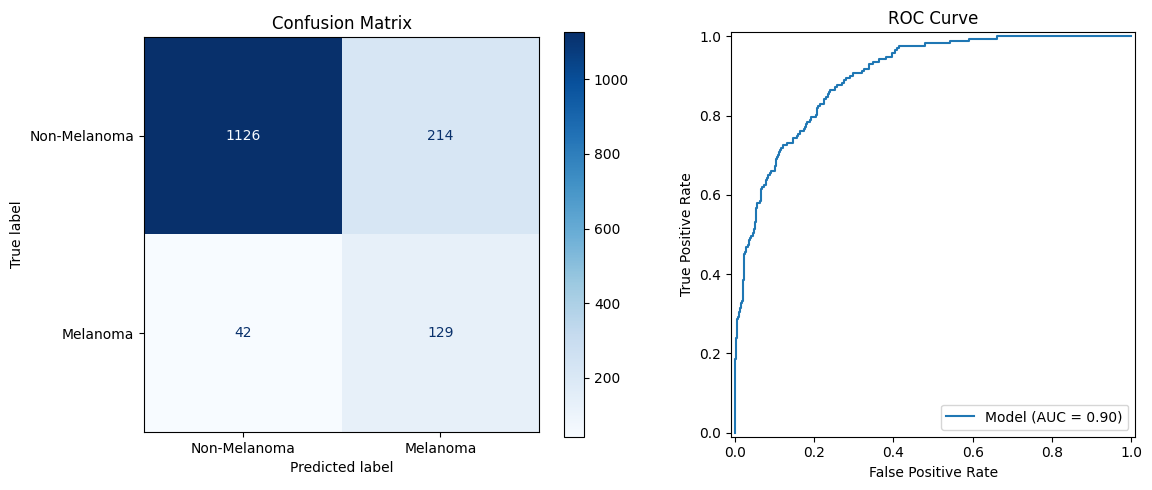

In [15]:
evaluate_model(model, test_loader, device, threshold=best_threshold)